In [1]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import os
from mpl_toolkits import mplot3d

from plotly.offline import download_plotlyjs, init_notebook_mode
from plotly.offline import plot, iplot
import plotly.graph_objects as go
%matplotlib inline

In [2]:
#Creating a path 
path = r"/Users/tiffanib./Desktop/Career Foundry Data Analytics/Machine Learning with Python/Data Sets/"

In [3]:
path

'/Users/tiffanib./Desktop/Career Foundry Data Analytics/Machine Learning with Python/Data Sets/'

In [4]:
#importing climate data set
climatedf = pd.read_csv(os.path.join(path, "Dataset-weather-prediction-dataset-processed_scaled.csv"))

In [5]:
#reducing the mean temperatures
df = climatedf[['DATE','MONTH','BASEL_temp_mean',
 'BELGRADE_temp_mean',
 'BUDAPEST_temp_mean',
 'DEBILT_temp_mean',
 'DUSSELDORF_temp_mean',
 'GDANSK_temp_mean',
 'HEATHROW_temp_mean',
 'KASSEL_temp_mean',
 'LJUBLJANA_temp_mean',
 'MAASTRICHT_temp_mean',
 'MADRID_temp_mean',
 'MUNCHENB_temp_mean',
 'OSLO_temp_mean',
 'ROMA_temp_mean',
 'SONNBLICK_temp_mean',
 'STOCKHOLM_temp_mean',
 'TOURS_temp_mean',
 'VALENTIA_temp_mean']].copy()              
              

In [6]:
df

,DATE,MONTH,BASEL_temp_mean,BELGRADE_temp_mean,BUDAPEST_temp_mean,DEBILT_temp_mean,DUSSELDORF_temp_mean,GDANSK_temp_mean,HEATHROW_temp_mean,KASSEL_temp_mean,LJUBLJANA_temp_mean,MAASTRICHT_temp_mean,MADRID_temp_mean,MUNCHENB_temp_mean,OSLO_temp_mean,ROMA_temp_mean,SONNBLICK_temp_mean,STOCKHOLM_temp_mean,TOURS_temp_mean,VALENTIA_temp_mean
0,19600101,1,-0.528623,-1.016876,-1.099163,-0.114356,-0.105836,-0.927601,-0.106469,-0.182904,-1.370824,-0.097084,-0.988280,-0.265742,-0.186575,-1.280450,-0.124331,-0.391072,-0.257321,-0.668215
1,19600102,1,-0.582946,-1.107669,-1.110927,-0.367511,-0.370915,-0.825294,-0.892676,-0.212437,-1.043881,-0.232112,-0.691740,-0.353714,-0.368598,-0.539569,-0.650834,-0.415953,-0.335759,-0.548046
2,19600103,1,-0.257010,-1.084971,-1.063873,-0.509912,-0.532908,-0.940389,-0.490837,-0.389635,-0.741156,-0.487164,-0.853490,-0.403983,-0.550620,-0.876333,-0.650834,-0.615003,-0.210258,-0.067372
3,19600104,1,-0.555784,-1.209812,-1.146217,-0.525734,-0.577088,-1.042696,-0.316124,-0.493001,-0.910682,-0.472161,-0.624345,-0.642763,-0.417137,-0.775304,-0.943336,-0.764290,-0.069069,-0.998679
4,19600105,1,-1.003946,-1.209812,-1.087400,-0.320045,-0.444548,-0.978754,-0.403481,-0.552067,-0.862246,-0.307127,-0.381721,-0.906678,-0.332193,-0.926848,-0.621584,-0.503037,-0.037694,-1.509396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22945,20221027,10,0.747959,0.628750,-0.005167,0.898267,1.042841,0.440753,0.906865,-0.005705,0.481853,1.268193,0.683127,0.664244,0.395898,-0.000746,0.826301,0.517090,1.295755,-0.007287
22946,20221028,10,0.856604,0.367720,-0.005167,0.945734,1.278467,0.466330,0.802037,-0.005705,0.263891,1.313202,0.561815,0.890456,0.541516,-0.000746,1.074927,0.641496,1.358505,-0.007287
22947,20221029,10,0.856604,0.083991,-0.005167,0.914089,1.101748,0.786039,0.924336,-0.005705,0.300218,1.208181,0.548336,1.053832,0.395898,-0.000746,1.221178,0.716139,1.405568,-0.007287
22948,20221030,10,0.680055,0.265577,-0.005167,0.692578,0.880848,0.376811,0.697210,-0.005705,0.397090,0.923123,0.103526,0.689378,-0.065226,-0.000746,1.235803,0.019467,0.668249,-0.007287


In [7]:
#Dropping the DATE and MONTH data as those numbers are not scaled with the rest.
notemp = df.drop(['DATE', 'MONTH'], axis=1)

In [8]:
#Looking at a whisker plot of the data to see the different variation in temperatures
notemp.boxplot(figsize=(15,15))
plt.xticks(rotation=90)

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18]),
 [Text(1, 0, 'BASEL_temp_mean'),
  Text(2, 0, 'BELGRADE_temp_mean'),
  Text(3, 0, 'BUDAPEST_temp_mean'),
  Text(4, 0, 'DEBILT_temp_mean'),
  Text(5, 0, 'DUSSELDORF_temp_mean'),
  Text(6, 0, 'GDANSK_temp_mean'),
  Text(7, 0, 'HEATHROW_temp_mean'),
  Text(8, 0, 'KASSEL_temp_mean'),
  Text(9, 0, 'LJUBLJANA_temp_mean'),
  Text(10, 0, 'MAASTRICHT_temp_mean'),
  Text(11, 0, 'MADRID_temp_mean'),
  Text(12, 0, 'MUNCHENB_temp_mean'),
  Text(13, 0, 'OSLO_temp_mean'),
  Text(14, 0, 'ROMA_temp_mean'),
  Text(15, 0, 'SONNBLICK_temp_mean'),
  Text(16, 0, 'STOCKHOLM_temp_mean'),
  Text(17, 0, 'TOURS_temp_mean'),
  Text(18, 0, 'VALENTIA_temp_mean')])

In [9]:
#Reducing the dataset down to a single year
dfyear = df[df['DATE'].astype(str).str.startswith('1965')]
dfyear = dfyear.head(365)

In [10]:
dfyear.describe()

,DATE,MONTH,BASEL_temp_mean,BELGRADE_temp_mean,BUDAPEST_temp_mean,DEBILT_temp_mean,DUSSELDORF_temp_mean,GDANSK_temp_mean,HEATHROW_temp_mean,KASSEL_temp_mean,LJUBLJANA_temp_mean,MAASTRICHT_temp_mean,MADRID_temp_mean,MUNCHENB_temp_mean,OSLO_temp_mean,ROMA_temp_mean,SONNBLICK_temp_mean,STOCKHOLM_temp_mean,TOURS_temp_mean,VALENTIA_temp_mean
count,3.650000e+02,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,1.965067e+07,6.526027,-0.153685,-0.118241,-0.199376,-0.213667,-0.169261,-0.192603,-0.231783,-0.091392,-0.195355,-0.213040,-0.125286,-0.181868,-0.174673,-0.072897,-0.259402,-0.194068,-0.197622,-0.140707
std,3.454755e+02,3.452584,0.918400,0.969571,0.968540,0.890460,0.887817,0.968254,0.936728,0.959712,0.964366,0.897518,1.000930,0.943657,0.990180,1.078735,1.031817,0.986306,0.873486,1.166267
min,1.965010e+07,1.000000,-2.239786,-2.390123,-2.146106,-2.361113,-2.064478,-2.820277,-2.430148,-2.264984,-2.048928,-2.317536,-2.080087,-2.490168,-2.649950,-2.442287,-3.093225,-2.356684,-2.171212,-2.981462
25%,1.965040e+07,4.000000,-0.908881,-0.926083,-1.134453,-0.937112,-0.871621,-0.965966,-0.980032,-0.935997,-1.177080,-0.907249,-0.934364,-0.919246,-0.963205,-0.859495,-1.001836,-0.963339,-0.853451,-0.878510
50%,1.965070e+07,7.000000,-0.121203,-0.154341,-0.193381,-0.193467,-0.105836,-0.134723,-0.123940,-0.079538,-0.172033,-0.097084,-0.152577,-0.177771,-0.040957,-0.135452,-0.168206,-0.142261,-0.100445,-0.037330
75%,1.965100e+07,10.000000,0.517087,0.685496,0.606530,0.581822,0.556862,0.632578,0.539968,0.717855,0.578725,0.533044,0.710085,0.526002,0.699269,0.773811,0.489923,0.728580,0.464310,0.803851
max,1.965123e+07,12.000000,1.875153,1.865807,1.782871,1.467867,1.779173,1.681223,1.640658,1.899177,1.934934,1.643269,2.017557,1.958683,1.706462,2.221898,1.937808,1.524777,1.562444,2.245875


In [11]:
#picking which weather station I am using. Below is a 3D visualization of the temperatures for that year.

In [12]:
#dropping the DATE and MONTH data as those numbers are not scaled with the rest.
notempyear = dfyear.drop(['DATE','MONTH'], axis=1)

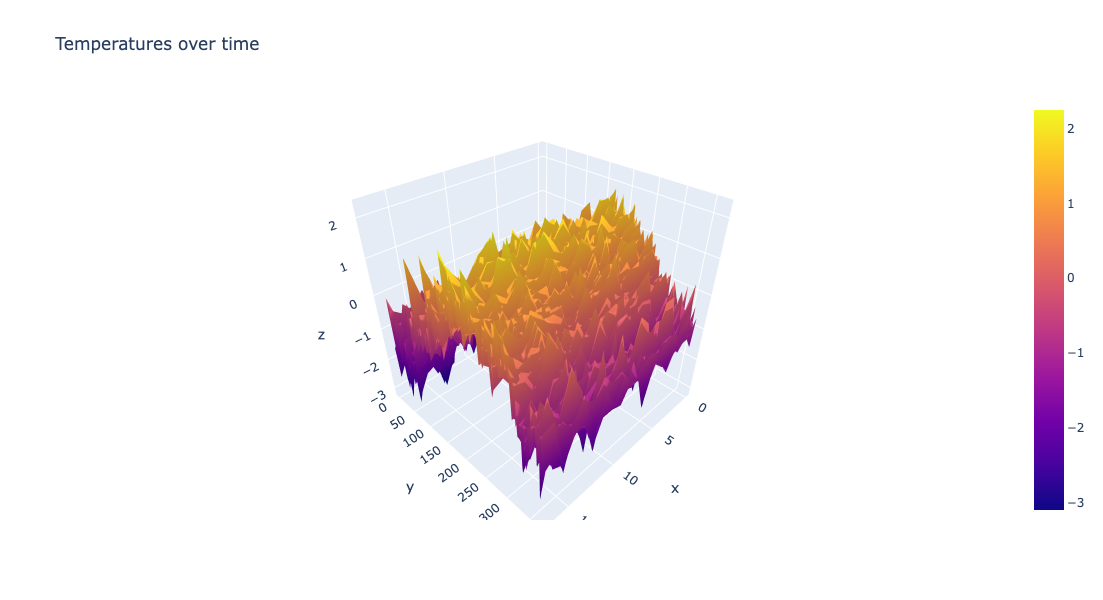

In [13]:
#Plotting all weather data for all stations for a year

#X = weather station
#Y = Day of the year
#Z = Temperature

fig = go.Figure(data=[go.Surface(z=notempyear.values)])
fig.update_layout(title='Temperatures over time', autosize=False,
                  width=600, height=600)
fig.show()

In [14]:
#creating an index for the year from 1 to 365 then scaling it by 100.
i = np.arange(0.01,3.66,0.01)
index = pd.DataFrame(data = i, columns = ['index'])
index

,index
0,0.01
1,0.02
2,0.03
3,0.04
4,0.05
...,...
360,3.61
361,3.62
362,3.63
363,3.64


In [15]:
n_rows = dfyear.shape[0]
n_rows

365

In [16]:
#translating weather data into the x and y datasets for optimization
X=index.to_numpy().reshape(n_rows,1)
ones = np.ones((n_rows,1))
X = np.concatenate((ones, X), axis=1)
y=dfyear['BASEL_temp_mean'].to_numpy().reshape(n_rows,1)

In [17]:
X.shape, y.shape

((365, 2), (365, 1))

<Figure size 600x400 with 0 Axes>

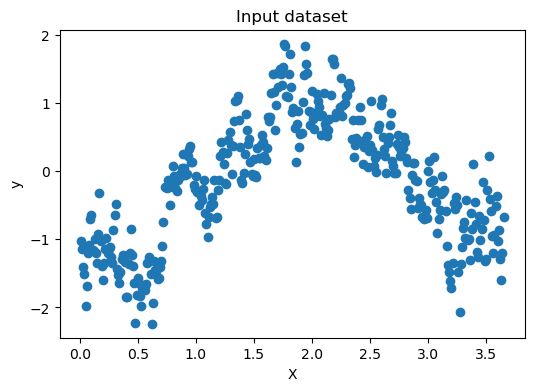

In [24]:
#visualizing 1965 weather year over time
plt.scatter(x=index['index'], y=dfyear['BASEL_temp_mean'])
plt.xlabel('X'); plt.ylabel('y');
plt.title('Input dataset');
plt.show()

In [26]:
#The mean temperature
dfyear['BASEL_temp_mean'].min()

-2.239785575778224

In [27]:
#The max temperature
dfyear['BASEL_temp_mean'].max()

1.8751529704509409

In [28]:
#Computing the loss function for the gradiant descent.

def compute_cost(X, y, theta=np.array([[0],[0]])):
    """Given covariate matrix X, the prediction results y and coefficients theta
    compute the loss"""
    
    m = len(y)
    J=0 # initialize loss to zero
    
    # reshape theta
    theta=theta.reshape(2,1)
    
    # calculate the hypothesis - y_hat
    h_x = np.dot(X,theta)
    #print(h_x)
    
    # subtract y from y_hat, square and sum
    error_term = sum((h_x - y)**2)
    
    # divide by twice the number of samples - standard practice.
    loss = error_term/(2*m)
    
    return loss

In [29]:
compute_cost(X,y)

array([0.43238347])

In [30]:
#This is the gradiant descent function. 

def gradient_descent(X, y, theta=np.array([[0],[0]]),
                    alpha=0.01, num_iterations=1500):
    """
    Solve for theta using Gradient Descent optimiztion technique. 
    Alpha is the learning rate
    """
    m = len(y)
    J_history = []
    theta0_history = []
    theta1_history = []
    theta = theta.reshape(2,1)
    
    for i in range(num_iterations):
        error = (np.dot(X, theta) - y)
        
        term0 = (alpha/m) * sum(error* X[:,0].reshape(m,1))
        term1 = (alpha/m) * sum(error* X[:,1].reshape(m,1))
        
        # update theta
        term_vector = np.array([[term0],[term1]])
        #print(term_vector)
        theta = theta - term_vector.reshape(2,1)
        
        # store history values
        theta0_history.append(theta[0].tolist()[0])
        theta1_history.append(theta[1].tolist()[0])
        J_history.append(compute_cost(X,y,theta).tolist()[0])
        
    return (theta, J_history, theta0_history, theta1_history)

In [31]:
%%time
#This runs your data through a gradiant descent for the starting conditions in 'theta_init.'


num_iterations=500 #<---Decide how many iterations you need. Start small and work up. Over 10,000 iterations will take a few seconds.
theta_init=np.array([[-10],[-5]]) #<---this is where you put the guess for [theta0], [theta1]. Start with 1 and 1.
alpha=0.1 #<---Decide what your step size is. Try values between 0.1 and 0.00001. You will need to adjust your iterations.
#If your solution is not converging, try a smaller step size.
theta, J_history, theta0_history, theta1_history = gradient_descent(X,y, theta_init,
                                                                   alpha, num_iterations)

CPU times: user 192 ms, sys: 5.21 ms, total: 197 ms
Wall time: 195 ms


In [32]:
theta

array([[-0.53307673],
       [ 0.20730171]])

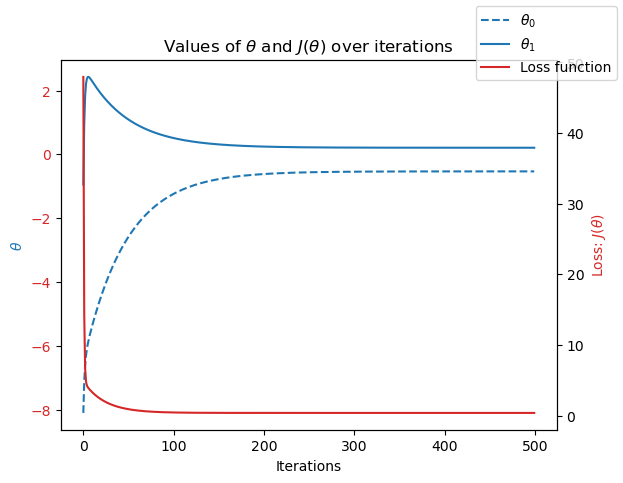

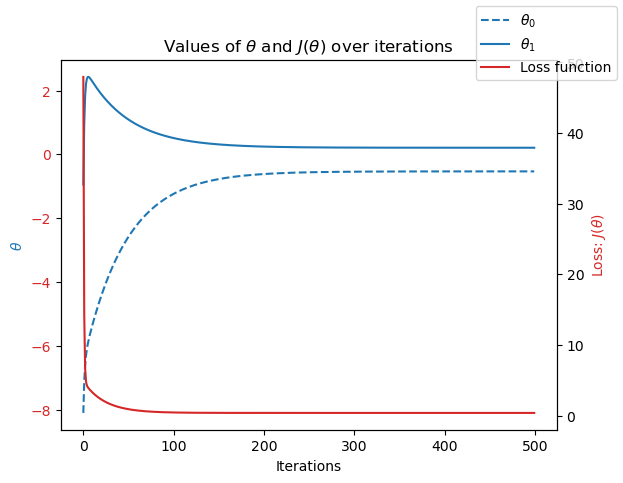

In [34]:
#plotting the loss, theta0, and theta1.

fig, ax1 = plt.subplots()

# plot thetas over time
color='tab:blue'
ax1.plot(theta0_history, label='$\\theta_{0}$', linestyle='--', color=color)
ax1.plot(theta1_history, label='$\\theta_{1}$', linestyle='-', color=color)
# ax1.legend()
ax1.set_xlabel('Iterations'); ax1.set_ylabel('$\\theta$', color=color);
ax1.tick_params(axis='y', labelcolor=color)

# plot loss function over time
color='tab:red'
ax2 = ax1.twinx()
ax2.plot(J_history, label='Loss function', color=color)
ax2.set_title('Values of $\\theta$ and $J(\\theta)$ over iterations')
ax2.set_ylabel('Loss: $J(\\theta)$', color=color)
ax1.tick_params(axis='y', labelcolor=color)

# ax2.legend();
fig.legend();

plt.show()


In [35]:
%%time
# theta range
theta0_vals = np.linspace(-10,10,100) #Look in the chart above for the limits of where theta0 and theta1 appear.
theta1_vals = np.linspace(-10,10,100) #Put those values as the first two "linspace" numbers in these lines
                                      #Select with large margins, maybe +/- 10
J_vals = np.zeros((len(theta0_vals), len(theta1_vals)))

# compute cost for each combination of theta
c1=0; c2=0
for i in theta0_vals:
    for j in theta1_vals:
        t = np.array([i, j])
        J_vals[c1][c2] = compute_cost(X, y, t.transpose()).tolist()[0]
        c2=c2+1
    c1=c1+1
    c2=0 # reinitialize to 0

CPU times: user 1.13 s, sys: 44.4 ms, total: 1.17 s
Wall time: 1.14 s


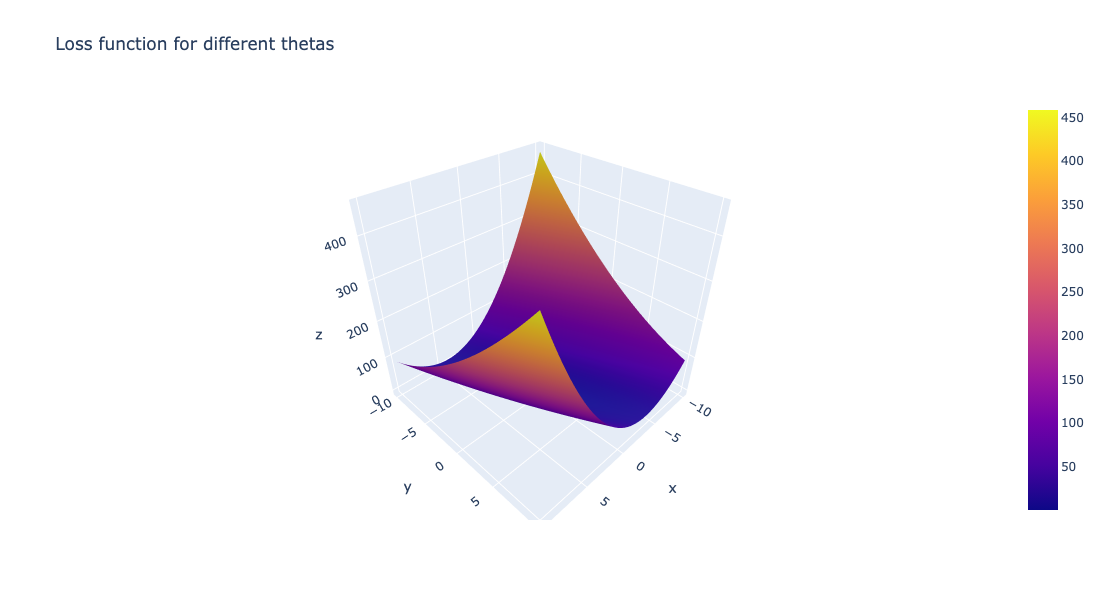

In [36]:
#this figure shows the loss function

#X = Theta0
#Y = Theta1
#Z = Loss
#Finding where it is closest to 0 in X and Y

fig = go.Figure(data=[go.Surface(x=theta1_vals, y=theta0_vals, z=J_vals)])
fig.update_layout(title='Loss function for different thetas', autosize=True,
                  width=600, height=600, xaxis_title='theta0', 
                 yaxis_title='theta1')
fig.show()

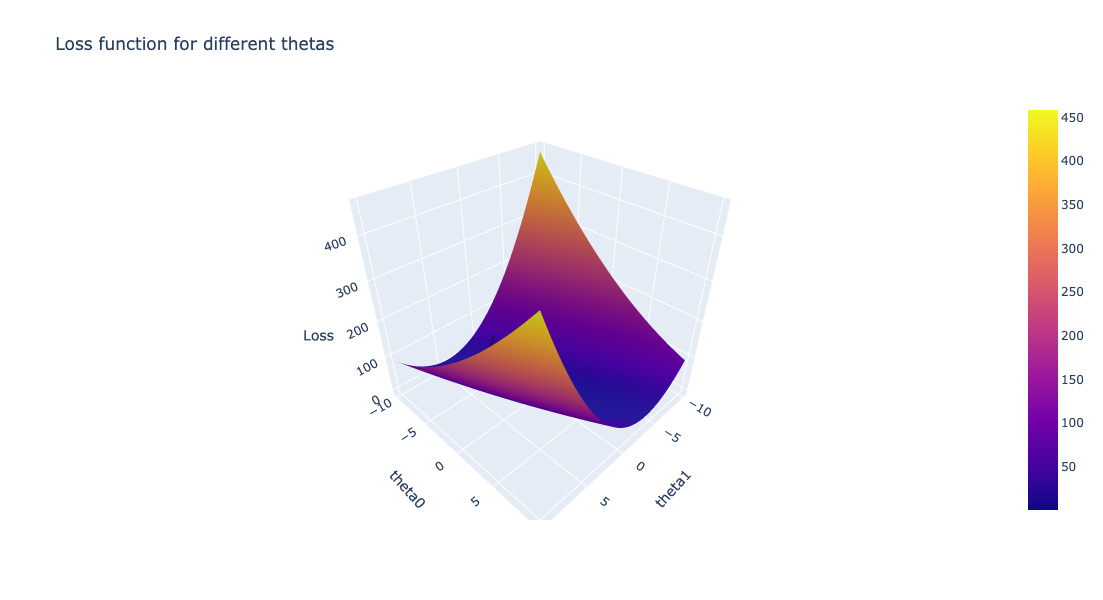

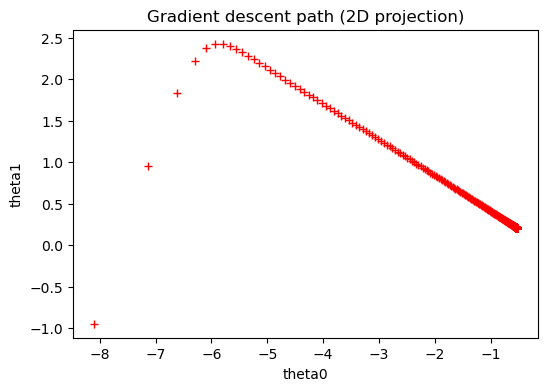

In [40]:
# X = theta0
# Y = theta1
# Z = Loss
# black line = path of loss function over the iterations

# ---------- Plotly 3D surface ----------
line_marker = dict(color='#101010', width=2)

fig = go.Figure()

fig.add_surface(
    x=theta1_vals,
    y=theta0_vals,
    z=J_vals,
    colorscale='Plasma',
    showscale=True)

fig.add_scatter3d(
    x=theta1_history,
    y=theta0_history,
    z=J_history,
    mode='lines',
    line=line_marker,
    name='Gradient descent path')

fig.update_layout(
    title='Loss function for different thetas',
    autosize=True,
    width=600,
    height=600,
    scene=dict(
        xaxis_title='theta1',
        yaxis_title='theta0',
        zaxis_title='Loss'))

fig.show()
# ---------- Matplotlib 2D projection ----------
plt.figure(figsize=(6, 4))

plt.plot(theta0_history, theta1_history, 'r+')
plt.xlabel('theta0')
plt.ylabel('theta1')
plt.title('Gradient descent path (2D projection)')

plt.show()

In [41]:
#rerunning the optimization above.
num_iterations=500 
theta_init=np.array([[1],[1]]) 
alpha= 0.1 
theta1, J_history1, theta0_history1, theta1_history1 = gradient_descent(X,y, theta_init,
                                                                   alpha, num_iterations)

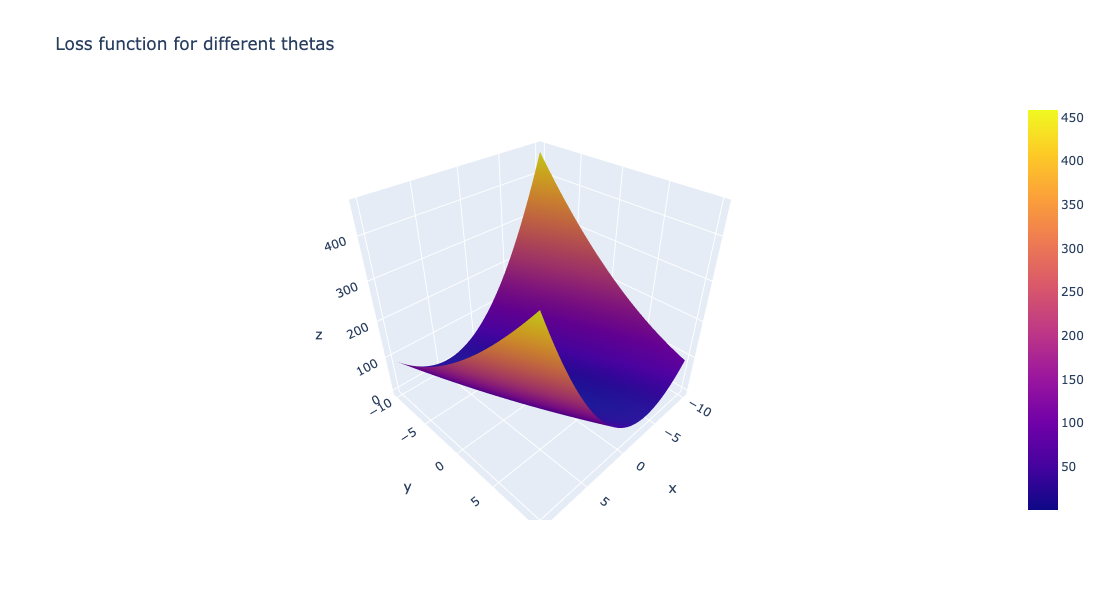

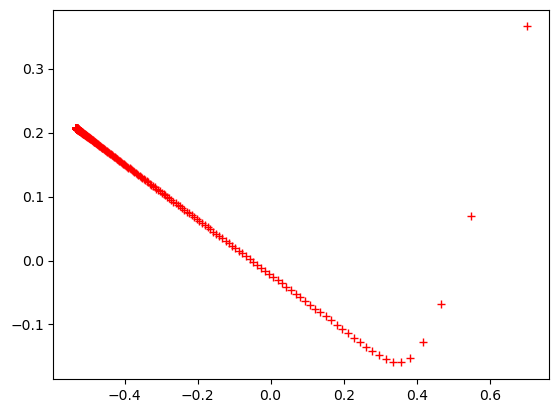

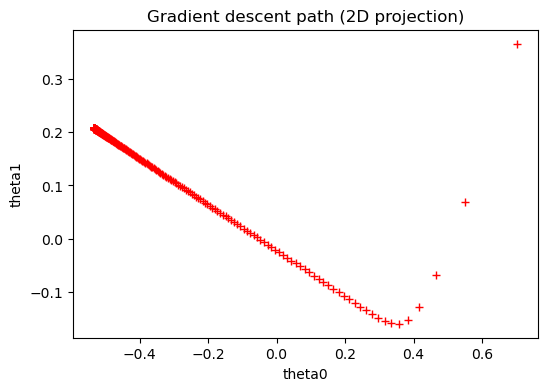

In [46]:
#New loss path on the function.
line_marker = dict(color='#101010', width=2)
fig = go.Figure()
fig.add_surface(x=theta1_vals, y=theta0_vals, z=J_vals)
fig.add_scatter3d(x=theta1_history1, y=theta0_history1, z=J_history1, line=line_marker, name='')
#The below line adds a graph of just the loss over iterations in a 2D plane
plt.plot(theta0_history1, theta1_history1, 'r+');
fig.update_layout(title='Loss function for different thetas', autosize=True,
                  width=600, height=600, xaxis_title='theta0', 
                 yaxis_title='theta1')
fig.show()
# ---------- Matplotlib 2D plot  ----------
plt.figure(figsize=(6, 4))

plt.plot(theta0_history1, theta1_history1, 'r+')
plt.xlabel('theta0')
plt.ylabel('theta1')
plt.title('Gradient descent path (2D projection)')

plt.show()

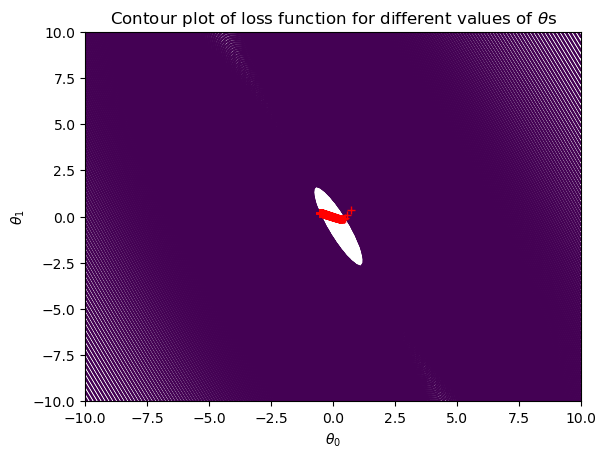

In [48]:
#this shows the convergence
plt.contour(theta0_vals, theta1_vals, J_vals, levels = np.logspace(0,10,1000))
plt.xlabel('$\\theta_{0}$'); plt.ylabel("$\\theta_{1}$")
plt.title("Contour plot of loss function for different values of $\\theta$s");
plt.plot(theta0_history1, theta1_history1, 'r+');

plt.show()